# Instance Space Analysis

This notebook implements the second analytical stage. Each selected M4 Monthly series is represented through complexity features, reduced to a two-dimensional PCA instance space, and then used to visualise forecasting error and best-model behaviour across the feature space.

**Report references:** Sections 2.1 (*Complexity Measures*), 2.4 (*Instance Spaces*), 4.2 (*Instance Space Analysis*), 4.2.1 (*Principal Component Analysis*), 4.2.2 (*Complexity Features and Forecasting Error*), 4.2.3 (*Best Model Assignment and Confidence Regions*), and Appendix C.

## 1. Libraries, reproducibility, and plotting setup

This cell imports the numerical, visualisation, feature-extraction, and dimensionality-reduction libraries required to construct the instance space. The fixed seed keeps the analysis reproducible, while the plotting configuration standardises the figures exported for the report.

**Report references:** Sections 2.1 (*Complexity Measures*) and 4.2.1 (*Principal Component Analysis*).


In [1]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from scipy import stats
from scipy.stats import kurtosis, skew, spearmanr
from scipy.special import digamma
from math import factorial

import antropy as ant
import ordpy 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from datasetsforecast.m4 import M4

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

#Plot style
plt.rcParams.update({
    'font.family':    'sans-serif',
    'font.size':      9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
})
sns.set_style("whitegrid")

## 2. Load the M4 Monthly data and the shared results table

The empirical study is based on the M4 Monthly subset. The full time-series table is loaded to compute complexity features, while `final_df.csv` stores the selected series, forecasting errors, and metadata produced by the forecasting notebooks.

**Report references:** Sections 3.1 (*Data*) and 3.2 (*Methodology*).

In [2]:
M4.download(directory="data", group="Monthly")
df, *_ = M4.load(directory="../data", group="Monthly")

final_df = pd.read_csv("../random_Forest_and_LightGBM_implementation/final_df.csv")

print(f"M4 Monthly: total series : {df['unique_id'].nunique()}")
print(f"final_df:   series       : {len(final_df)}")
print(f"final_df:   columns      : {list(final_df.columns)}")

M4 Monthly: total series : 48000
final_df:   series       : 400
final_df:   columns      : ['unique_id', 'size', 'complexity', 'transformations', 'n_transformations', 'final_status', 'nmae_AutoARIMA', 'nrmse_AutoARIMA', 'smape_AutoARIMA', 'nmae_naive', 'nrmse_naive', 'smape_naive', 'nmae_seasonal_naive', 'nrmse_seasonal_naive', 'smape_seasonal_naive', '%nmae_arima_vs_snaive', '%nrmse_arima_vs_snaive', '%smape_arima_vs_snaive', '%nmae_arima_vs_naive', '%nrmse_arima_vs_naive', '%smape_arima_vs_naive', 'nmae_RF', 'nrmse_RF', 'smape_RF', 'nmae_LGBM', 'nrmse_LGBM', 'smape_LGBM', '%nmae_rf_vs_snaive', '%nrmse_rf_vs_snaive', '%smape_rf_vs_snaive', '%nmae_rf_vs_naive', '%nrmse_rf_vs_naive', '%smape_rf_vs_naive', '%nmae_lgbm_vs_snaive', '%nrmse_lgbm_vs_snaive', '%smape_lgbm_vs_snaive', '%nmae_lgbm_vs_naive', '%nrmse_lgbm_vs_naive', '%smape_lgbm_vs_naive']


## 3. Compute the complexity feature set

This cell defines and computes the complexity features used to describe each time series. The feature set extends the initial Complexity Estimate (CE) with entropy, compressibility, ordinal-pattern, spectral, skewness, and kurtosis measures. These features form the high-dimensional representation that is later projected into the instance space.

**Report references:** Section 2.1 (*Complexity Measures*), Table 1 (*Complexity Features Selected*), and Section 3.2 (*Complexity Features Set*).

In [3]:
def _robust_histogram(x, bins='fd'):
    try:
        counts, _ = np.histogram(x, bins=bins)
        if len(counts) < 2:
            raise ValueError
    except Exception:
        counts, _ = np.histogram(x, bins='sturges')
    return counts[counts > 0]

def lempel_ziv(x):
    return float(ant.lziv_complexity(x > np.median(x), normalize=True))

def approximation_entropy(x, order=2):
    return float(ant.app_entropy(x, order=order))

def sample_entropy(x, order=2):
    return float(ant.sample_entropy(x, order=order))

def permutation_entropy(x, order=4, delay=1):
    return float(ant.perm_entropy(x, order=order, delay=delay, normalize=True))

def shannon_entropy_CS(x, bins='fd'):
    counts = _robust_histogram(x, bins).astype(float)
    n = counts.sum()
    if n == 0: return np.nan
    f1     = np.sum(counts == 1)
    C_hat  = 1.0 - (f1 / n)
    if C_hat <= 0:
        p = counts / n
        return float(-np.sum(p * np.log(p)))
    p_hat    = counts / n
    p_tilde  = C_hat * p_hat
    lambda_i = 1.0 - (1.0 - p_tilde) ** n
    lambda_i = np.where(lambda_i == 0, np.finfo(float).eps, lambda_i)
    return float(-np.sum((p_tilde / lambda_i) * np.log(p_tilde)))

def shannon_entropy_SG(x, bins='fd'):
    counts = _robust_histogram(x, bins).astype(float)
    n = counts.sum()
    if n == 0: return np.nan
    return float(digamma(n + 1) - (1.0 / n) * np.sum(counts * digamma(counts + 1)))

def spectral_entropy(x, sf=1.0):
    nperseg = min(len(x), 256)
    return float(ant.spectral_entropy(x, sf=sf, method='welch',
                                      nperseg=nperseg, normalize=False))

def nforbidden(x, order=4):
    patterns, _ = ordpy.ordinal_distribution(x, dx=order)
    return float((factorial(order) - len(patterns)) / factorial(order))

def kurtosis_feat(x):
    return float(kurtosis(x, fisher=True, bias=False))

def skewness_feat(x):
    return float(skew(x, bias=False))

FEATURE_FUNCS = {
    'lempel_ziv':            lempel_ziv,
    'approximation_entropy': approximation_entropy,
    'sample_entropy':        sample_entropy,
    'permutation_entropy':   permutation_entropy,
    'shannon_entropy_CS':    shannon_entropy_CS,
    'shannon_entropy_SG':    shannon_entropy_SG,
    'spectral_entropy':      spectral_entropy,
    'nforbidden':            nforbidden,
    'kurtosis':              kurtosis_feat,
    'skewness':              skewness_feat,
}

def compute_complexity_features(df, min_length=10):
    records = []
    for uid, grp in df.groupby('unique_id', sort=False):
        x = grp.sort_values('ds')['y'].dropna().astype(float).values
        row = ({name: func(x) for name, func in FEATURE_FUNCS.items()}
               if len(x) >= min_length
               else {f: np.nan for f in FEATURE_FUNCS})
        row['unique_id'] = uid
        records.append(row)
    return pd.DataFrame(records)

cols_to_drop = [c for c in FEATURE_FUNCS if c in final_df.columns]
cols_to_drop += [c for c in final_df.columns if c.endswith('_x') or c.endswith('_y')]
final_df = final_df.drop(columns=cols_to_drop, errors='ignore')

df_filtered   = df[df['unique_id'].isin(final_df['unique_id'])].copy()
complexity_df = compute_complexity_features(df_filtered).drop_duplicates('unique_id')
final_df      = final_df.merge(complexity_df, on='unique_id', how='left')

final_df = final_df.rename(columns={'complexity': 'complexity_estimate'})

NEW_FEATS = list(FEATURE_FUNCS.keys())
print(f"final_df shape: {final_df.shape}")
print("\nNaNs per feature:")
print(final_df[NEW_FEATS].isna().sum().to_string(), "\n")
desc_stats = (
    final_df[NEW_FEATS]
    .describe()
    .T
    .round(4)
)
display(desc_stats)

final_df shape: (400, 49)

NaNs per feature:
lempel_ziv               0
approximation_entropy    0
sample_entropy           0
permutation_entropy      0
shannon_entropy_CS       0
shannon_entropy_SG       0
spectral_entropy         0
nforbidden               0
kurtosis                 0
skewness                 0 



,count,mean,std,min,25%,50%,75%,max
lempel_ziv,400.0,0.4513,0.2538,0.0527,0.2541,0.4029,0.5921,1.2176
approximation_entropy,400.0,0.5359,0.2882,0.0220,0.2977,0.5305,0.7292,1.4139
sample_entropy,400.0,0.6452,0.5108,0.0172,0.2198,0.4992,0.9368,2.2228
permutation_entropy,400.0,0.8540,0.1419,0.1189,0.8059,0.8956,0.9506,0.9939
shannon_entropy_CS,400.0,1.9401,0.3213,0.8946,1.7207,1.9517,2.1582,3.1204
shannon_entropy_SG,400.0,1.9066,0.3168,0.8698,1.6909,1.9098,2.1306,3.0580
spectral_entropy,400.0,2.6951,1.2394,0.5610,1.7037,2.5247,3.5538,6.4183
nforbidden,400.0,0.0786,0.1393,0.0000,0.0000,0.0000,0.0833,0.8333
kurtosis,400.0,0.4195,6.6162,-1.7251,-0.9936,-0.6270,0.0501,100.4440
skewness,400.0,0.3555,0.9517,-2.8971,-0.1401,0.2362,0.7034,9.2401


## 4. Pairwise analysis of complexity features

Before PCA, this cell examines pairwise relationships between the selected complexity features. Strong correlations indicate redundancy between measures, which is relevant because PCA will combine correlated information into shared components. The resulting pairplot corresponds to the feature-correlation diagnostic presented in the appendix.

**Report references:** Section 4.2 (*Instance Space Analysis*) and Appendix C, Figure 9.

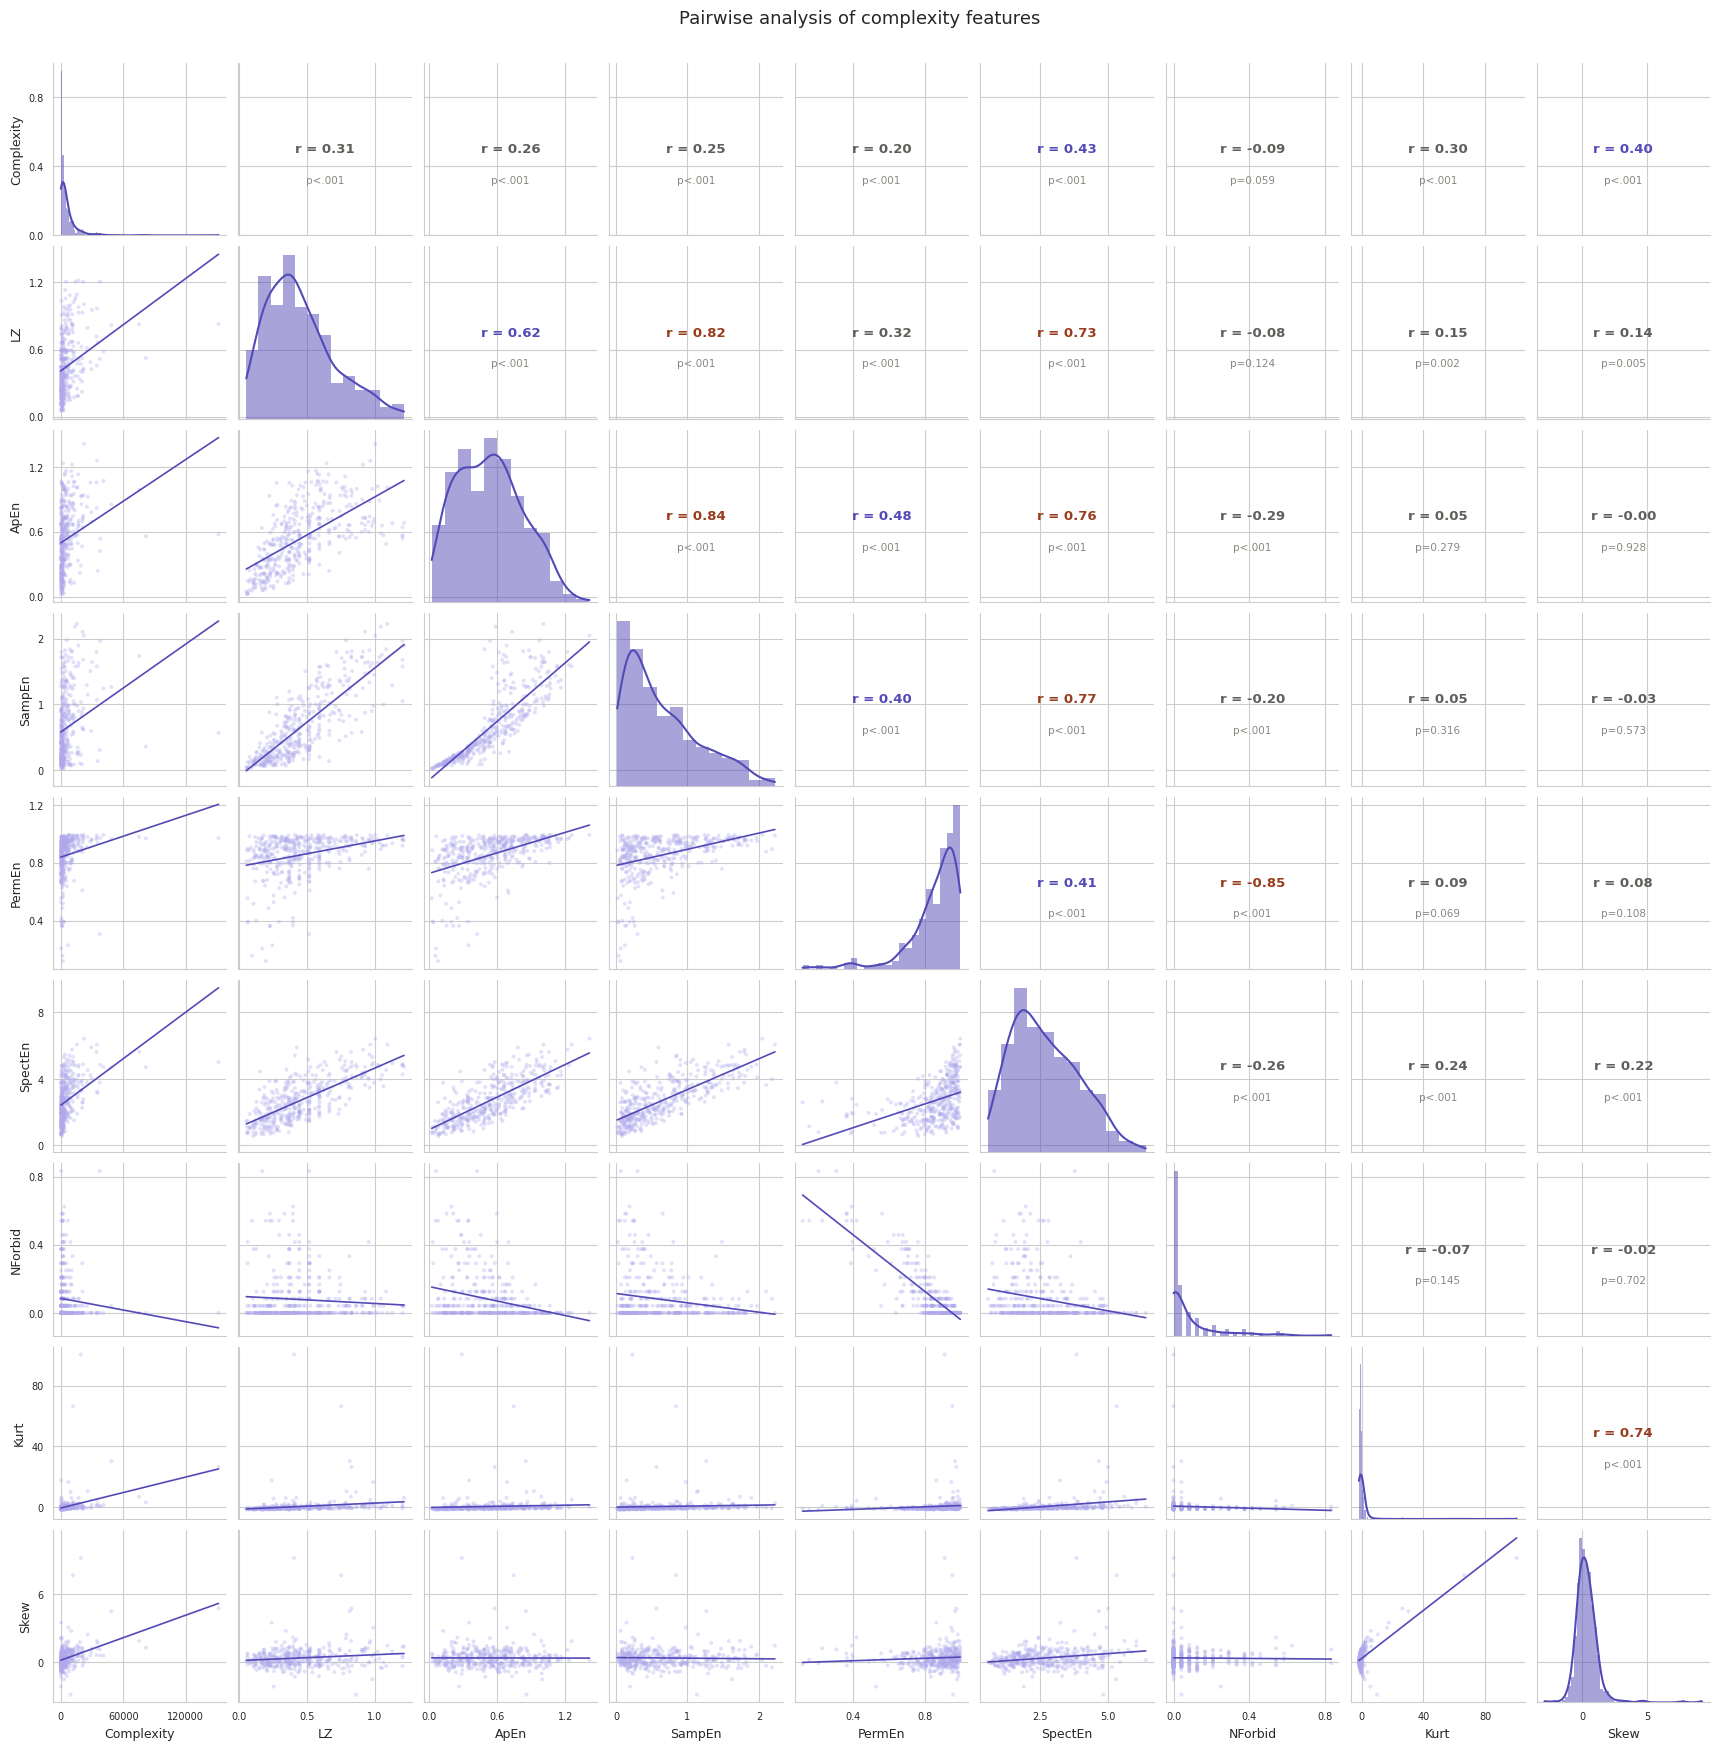

Saved: complexity_pairplot.png  (N = 400 series)


In [4]:
FEATURES_PLOT = [
    'complexity_estimate', 'lempel_ziv', 'approximation_entropy', 'sample_entropy',
    'permutation_entropy', 'spectral_entropy', 'nforbidden', 'kurtosis', 'skewness'
]
FEATURE_LABELS = {
    'complexity_estimate': 'Complexity', 'lempel_ziv': 'LZ',
    'approximation_entropy': 'ApEn', 'sample_entropy': 'SampEn',
    'permutation_entropy': 'PermEn', 'spectral_entropy': 'SpectEn',
    'nforbidden': 'NForbid', 'kurtosis': 'Kurt', 'skewness': 'Skew'
}

plot_df = (
    final_df[FEATURES_PLOT]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .rename(columns=FEATURE_LABELS)
)
short_labels = list(FEATURE_LABELS.values())

def corrfunc(x, y, **kws):
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3: return
    r, p = stats.pearsonr(x[mask], y[mask])
    color = '#993C1D' if abs(r) >= 0.7 else ('#534AB7' if abs(r) >= 0.4 else '#5F5E5A')
    ax = plt.gca()
    ax.annotate(f"r = {r:.2f}", xy=(0.5, 0.5), xycoords='axes fraction',
                ha='center', va='center', fontsize=9.5, fontweight='bold', color=color)
    p_str = "p<.001" if p < 0.001 else f"p={p:.3f}"
    ax.annotate(p_str, xy=(0.5, 0.32), xycoords='axes fraction',
                ha='center', va='center', fontsize=7.5, color='#888780')

g = sns.PairGrid(plot_df, vars=short_labels, diag_sharey=False, height=1.9, aspect=1.0)
g.map_lower(sns.regplot,
            scatter_kws={'s': 8, 'alpha': 0.35, 'color': '#AFA9EC', 'edgecolor': 'none'},
            line_kws={'color': '#534AB7', 'lw': 1.2}, ci=None)
g.map_diag(sns.histplot, kde=True, color='#534AB7', alpha=0.5, edgecolor='none',
           line_kws={'lw': 1.5})
g.map_upper(corrfunc)

for ax in g.axes.flat:
    if ax is None: continue
    ax.tick_params(labelsize=7, length=3)
    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.yaxis.set_major_locator(plt.MaxNLocator(3))

plt.suptitle("Pairwise analysis of complexity features", fontsize=13, y=1.015, fontweight='500')
plt.tight_layout(pad=0.4)
plt.savefig("complexity_pairplot.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: complexity_pairplot.png  (N = {len(plot_df)} series)")

## 5. Build the PCA-based two-dimensional instance space

This cell standardises the complexity-feature matrix and applies PCA to obtain PC1 and PC2. Standardisation is necessary because the features have different scales; without it, features with larger numerical ranges could dominate the principal components. The resulting coordinates are merged back into `final_df` so that forecasting errors can be plotted in the same space.

**Report references:** Sections 2.4 (*Instance Spaces*) and 4.2.1 (*Principal Component Analysis*), including Equation 8.

Series used in PCA: 400  (dropped: 0)


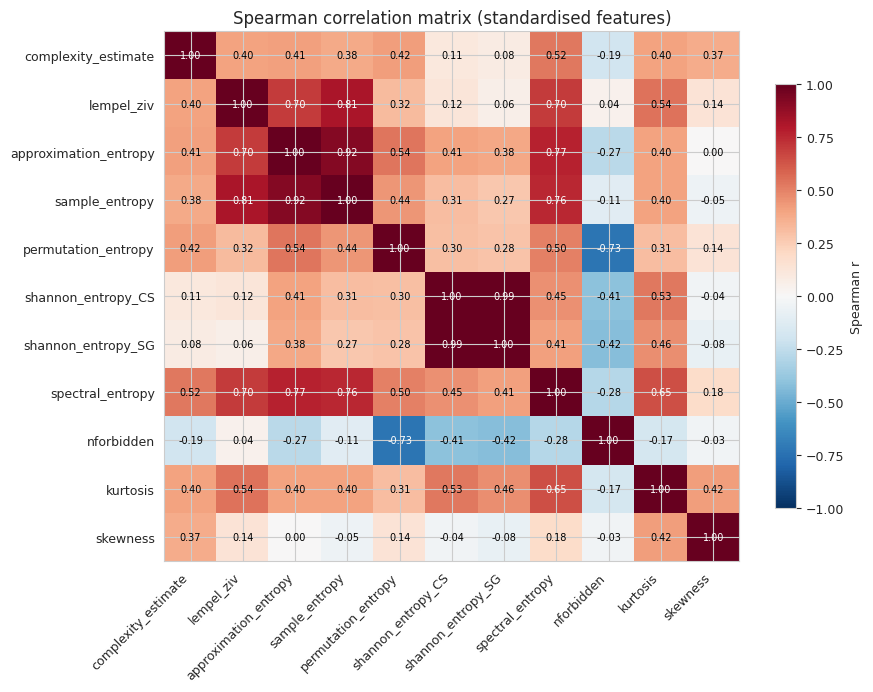

Saved: correlation_matrix.png


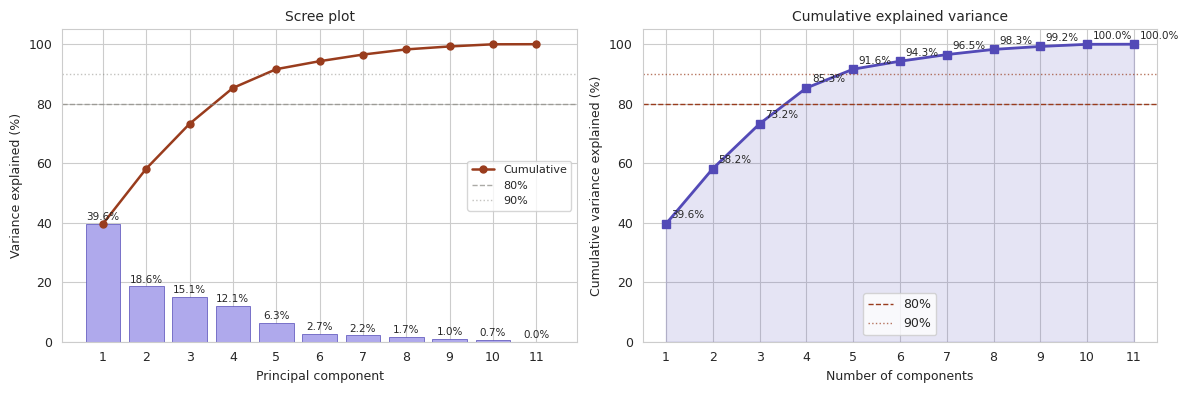

Saved: scree_plot.png

Variance explained per component:
  PC1:  39.6%   cumulative:  39.6%
  PC2:  18.6%   cumulative:  58.2% ← 2D projection
  PC3:  15.1%   cumulative:  73.2%
  PC4:  12.1%   cumulative:  85.3% ← crosses 80%
  PC5:   6.3%   cumulative:  91.6%
  PC6:   2.7%   cumulative:  94.3%
  PC7:   2.2%   cumulative:  96.5%
  PC8:   1.7%   cumulative:  98.3%
  PC9:   1.0%   cumulative:  99.2%
  PC10:   0.7%   cumulative: 100.0%
  PC11:   0.0%   cumulative: 100.0%

PC1 + PC2 explain 39.6% + 18.6% = 58.2% of total variance


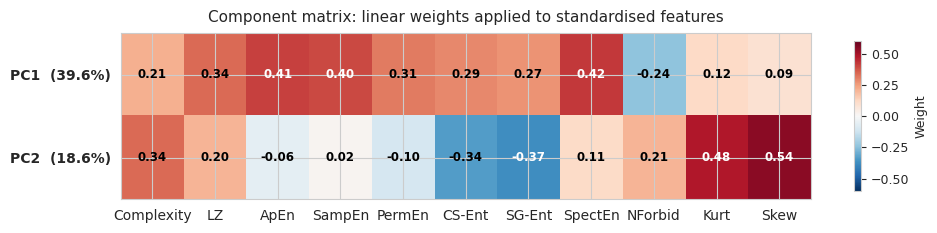

Saved: pca_component_matrix.png


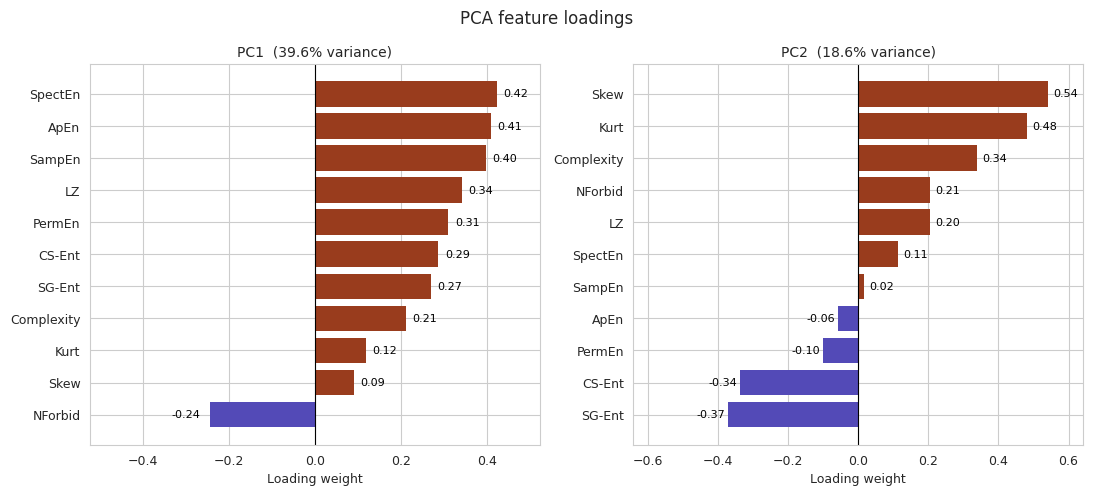

Saved: pca_loadings.png

Axis interpretation:

PC1
  Positive loadings: ['spectral_entropy', 'approximation_entropy', 'sample_entropy', 'lempel_ziv', 'permutation_entropy', 'shannon_entropy_CS', 'shannon_entropy_SG', 'complexity_estimate', 'kurtosis', 'skewness']
  Negative loadings: ['nforbidden']

PC2
  Positive loadings: ['skewness', 'kurtosis', 'complexity_estimate', 'nforbidden', 'lempel_ziv', 'spectral_entropy', 'sample_entropy']
  Negative loadings: ['shannon_entropy_SG', 'shannon_entropy_CS', 'permutation_entropy', 'approximation_entropy']


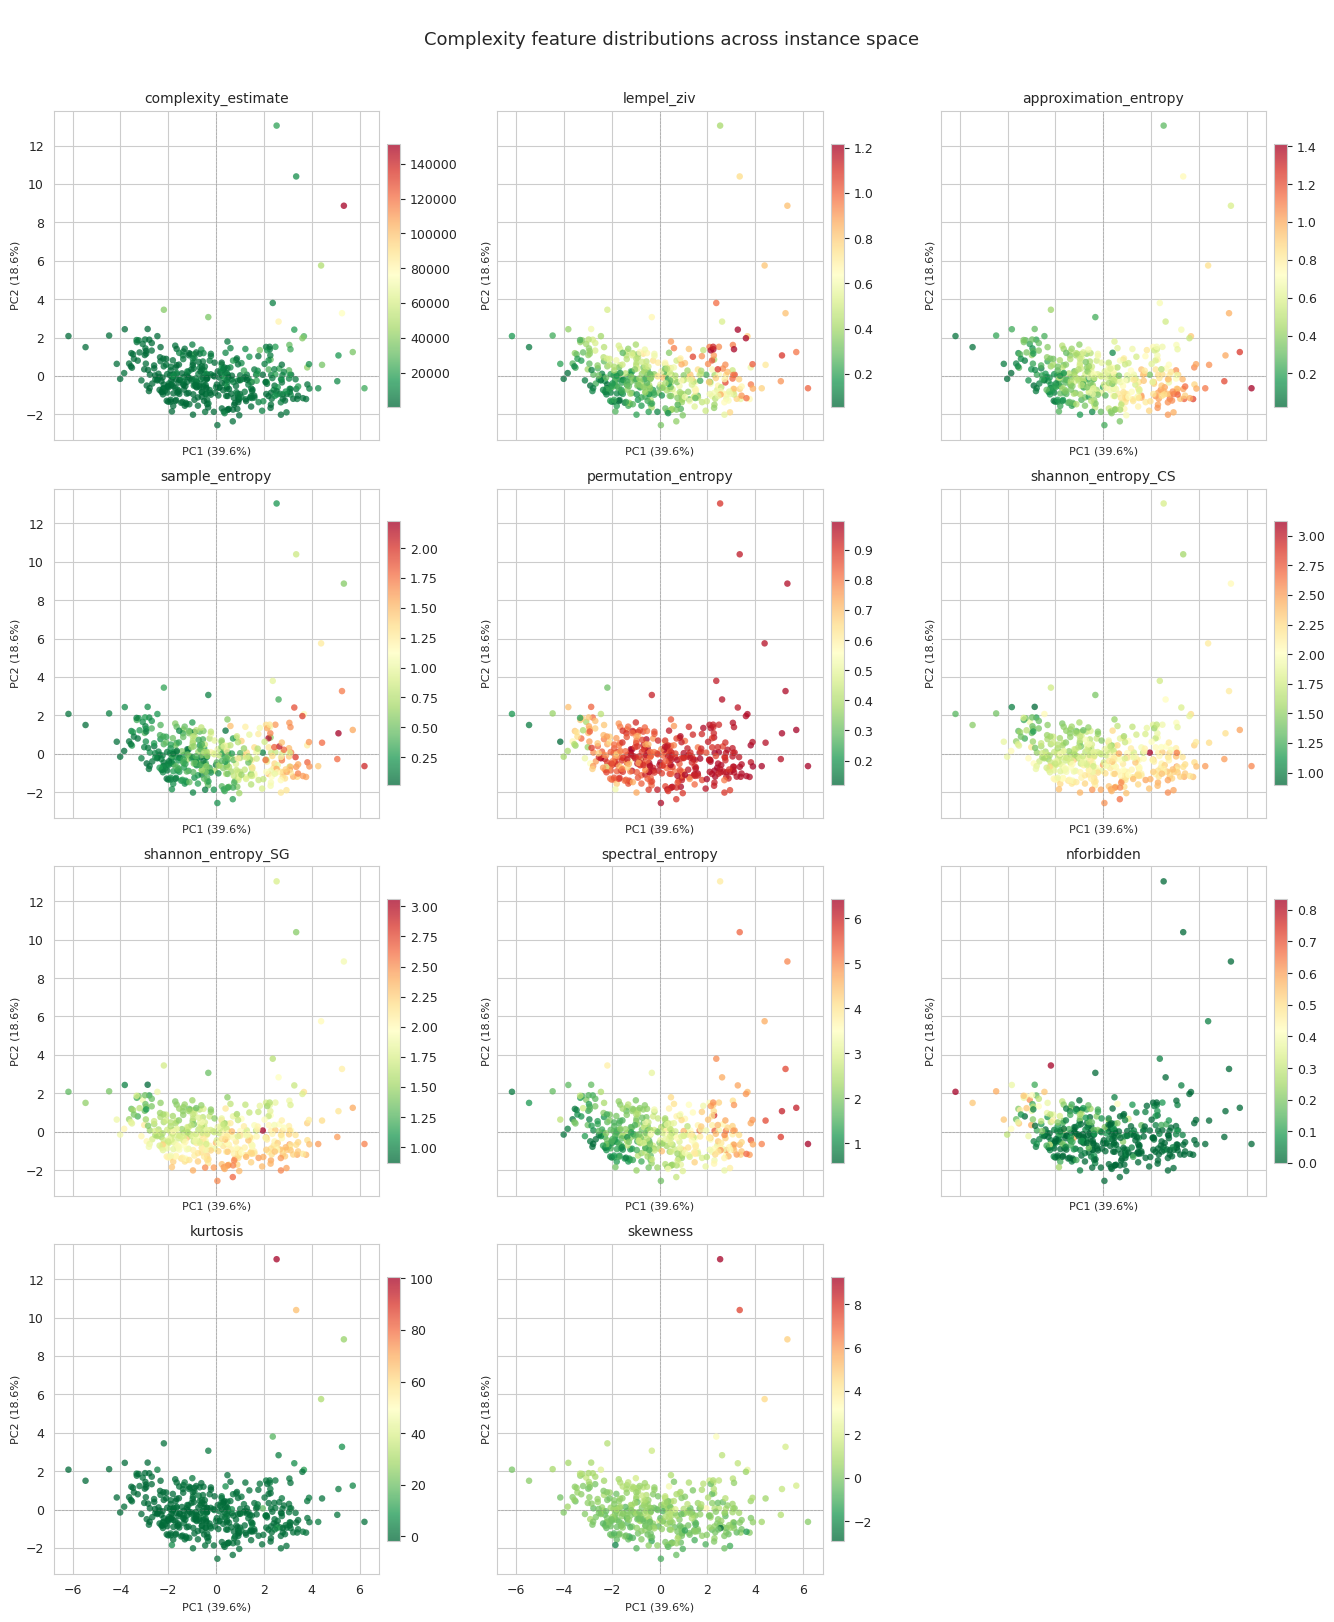

Saved: instance_space_features.png

PC1/PC2 merged into final_df  |  NaNs: PC1=0, PC2=0
final_df shape: (400, 51)


In [5]:
COMPLEXITY_FEATURES = [
    'complexity_estimate', 'lempel_ziv', 'approximation_entropy', 'sample_entropy',
    'permutation_entropy', 'shannon_entropy_CS', 'shannon_entropy_SG',
    'spectral_entropy', 'nforbidden', 'kurtosis', 'skewness'
]
FEATURES = [f for f in COMPLEXITY_FEATURES if f in final_df.columns]

work_df = (
    final_df[['unique_id'] + FEATURES]
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=FEATURES)
    .reset_index(drop=True)
)
print(f"Series used in PCA: {len(work_df)}  (dropped: {len(final_df) - len(work_df)})")

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(work_df[FEATURES].values)

#Spearman correlation heatmap
corr_matrix = pd.DataFrame(X_scaled, columns=FEATURES).corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8, label='Spearman r')
ax.set_xticks(range(len(FEATURES))); ax.set_yticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(FEATURES, fontsize=9)
for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        v = corr_matrix.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha='center', va='center', fontsize=7,
                color='white' if abs(v) > 0.6 else 'black')
ax.set_title('Spearman correlation matrix (standardised features)', fontsize=12)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: correlation_matrix.png")

#Scree plot
pca_full  = PCA(n_components=len(FEATURES)).fit(X_scaled)
explained = pca_full.explained_variance_ratio_ * 100
cumul     = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
bars = ax.bar(range(1, len(FEATURES)+1), explained, color='#AFA9EC', edgecolor='#534AB7', lw=0.5)
ax.plot(range(1, len(FEATURES)+1), cumul, marker='o', ms=5, color='#993C1D', lw=1.8, label='Cumulative')
ax.axhline(80, ls='--', lw=1, color='#888780', alpha=0.7, label='80%')
ax.axhline(90, ls=':',  lw=1, color='#888780', alpha=0.5, label='90%')
for bar, val in zip(bars, explained):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=7.5)
ax.set(xlabel='Principal component', ylabel='Variance explained (%)', title='Scree plot')
ax.legend(fontsize=8); ax.set_xticks(range(1, len(FEATURES)+1))

ax2 = axes[1]
ax2.plot(range(1, len(FEATURES)+1), cumul, marker='s', ms=6, color='#534AB7', lw=2)
ax2.fill_between(range(1, len(FEATURES)+1), cumul, alpha=0.15, color='#534AB7')
ax2.axhline(80, ls='--', lw=1, color='#993C1D', label='80%')
ax2.axhline(90, ls=':',  lw=1, color='#993C1D', alpha=0.7, label='90%')
ax2.set(xlabel='Number of components', ylabel='Cumulative variance explained (%)',
        title='Cumulative explained variance', ylim=(0, 105))
ax2.legend(fontsize=9); ax2.set_xticks(range(1, len(FEATURES)+1))
for i, cv in enumerate(cumul):
    ax2.annotate(f'{cv:.1f}%', (i+1, cv), textcoords='offset points', xytext=(4, 4), fontsize=7.5)
plt.tight_layout()
plt.savefig('scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: scree_plot.png")

print("\nVariance explained per component:")
for i, (e, c) in enumerate(zip(explained, cumul), 1):
    tag = ' ← 2D projection' if i == 2 else (' ← crosses 80%' if c >= 80 and cumul[i-2] < 80 else '')
    print(f"  PC{i}: {e:5.1f}%   cumulative: {c:5.1f}%{tag}")

#2D PCA
pca2   = PCA(n_components=2)
coords = pca2.fit_transform(X_scaled)
work_df['PC1'] = coords[:, 0]
work_df['PC2'] = coords[:, 1]
ev1, ev2 = pca2.explained_variance_ratio_ * 100
print(f"\nPC1 + PC2 explain {ev1:.1f}% + {ev2:.1f}% = {ev1+ev2:.1f}% of total variance")

#Component matrix
components_df = pd.DataFrame(
    pca2.components_, index=['PC1', 'PC2'], columns=FEATURES
)

SHORT = {
    'complexity_estimate': 'Complexity', 'lempel_ziv': 'LZ',
    'approximation_entropy': 'ApEn', 'sample_entropy': 'SampEn',
    'permutation_entropy': 'PermEn', 'shannon_entropy_CS': 'CS-Ent',
    'shannon_entropy_SG': 'SG-Ent', 'spectral_entropy': 'SpectEn',
    'nforbidden': 'NForbid', 'kurtosis': 'Kurt', 'skewness': 'Skew'
}
comp_display = components_df.rename(columns=SHORT).round(3)

#Heatmap-style component matrix
fig, ax = plt.subplots(figsize=(10, 2.4))
im = ax.imshow(comp_display.values, cmap='RdBu_r', vmin=-0.6, vmax=0.6, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.9, label='Weight')
ax.set_xticks(range(len(SHORT)))
ax.set_xticklabels(list(SHORT.values()), fontsize=10)
ax.set_yticks([0, 1])
ax.set_yticklabels([f'PC1  ({ev1:.1f}%)', f'PC2  ({ev2:.1f}%)'], fontsize=10, fontweight='bold')
for i in range(2):
    for j in range(len(FEATURES)):
        w = comp_display.values[i, j]
        ax.text(j, i, f"{w:.2f}", ha='center', va='center', fontsize=8.5,
                color='white' if abs(w) > 0.35 else 'black', fontweight='bold')
ax.set_title('Component matrix: linear weights applied to standardised features', fontsize=11, pad=8)
plt.tight_layout()
plt.savefig('pca_component_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pca_component_matrix.png")

#Loadings bar chart
loadings_plot = components_df.rename(columns=SHORT).T

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, pc, ev_pc in zip(axes, ['PC1', 'PC2'], [ev1, ev2]):
    vals = loadings_plot[pc].sort_values()
    colors = ['#993C1D' if v > 0 else '#534AB7' for v in vals]

    ax.barh(vals.index, vals.values, color=colors, edgecolor='none')
    ax.axvline(0, color='black', lw=0.8)

    # Add symmetric padding to avoid text-label overlap
    max_abs = np.max(np.abs(vals.values))
    ax.set_xlim(-max_abs - 0.10, max_abs + 0.10)

    ax.set_title(f'{pc}  ({ev_pc:.1f}% variance)')
    ax.set_xlabel('Loading weight')
    ax.tick_params(labelsize=9)

    for i, (feat, val) in enumerate(vals.items()):
        if val >= 0:
            x_pos = val + 0.015
            ha = 'left'
        else:
            x_pos = val - 0.09
            ha = 'left'
        ax.text(
            x_pos,
            i,
            f'{val:.2f}',
            va='center',
            ha=ha,
            fontsize=8,
            color='black'
        )

plt.suptitle('PCA feature loadings', fontsize=12)
plt.tight_layout()
plt.savefig('pca_loadings.png', dpi=300, bbox_inches='tight')
plt.savefig('pca_loadings.pdf', bbox_inches='tight')
plt.show()

print("Saved: pca_loadings.png")

print("\nAxis interpretation:")
for pc in ['PC1', 'PC2']:
    row = components_df.loc[pc]

    positive = row[row > 0].sort_values(ascending=False)
    negative = row[row < 0].sort_values()

    print(f"\n{pc}")

    if len(positive):
        print(f"  Positive loadings: {positive.index.tolist()}")

    if len(negative):
        print(f"  Negative loadings: {negative.index.tolist()}")

#Feature distribution across the instance space
n_feats = len(FEATURES)
ncols_f = 3
nrows_f = (n_feats + ncols_f - 1) // ncols_f

fig, axes = plt.subplots(nrows_f, ncols_f,
                         figsize=(ncols_f * 4.5, nrows_f * 4),
                         sharex=True, sharey=True)
axes = axes.flatten()
for i, feat in enumerate(FEATURES):
    ax   = axes[i]
    vals = work_df[feat]
    sc   = ax.scatter(work_df['PC1'], work_df['PC2'],
                      c=vals, cmap='RdYlGn_r', s=22, alpha=0.75, edgecolors='none')
    plt.colorbar(sc, ax=ax, shrink=0.8, pad=0.02)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel(f'PC1 ({ev1:.1f}%)', fontsize=8)
    ax.set_ylabel(f'PC2 ({ev2:.1f}%)', fontsize=8)
    ax.axhline(0, color='gray', lw=0.5, ls='--', alpha=0.5)
    ax.axvline(0, color='gray', lw=0.5, ls='--', alpha=0.5)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle('\nComplexity feature distributions across instance space', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('instance_space_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: instance_space_features.png")

#Merge coordinates back
if 'PC1' in final_df.columns:
    final_df = final_df.drop(columns=['PC1', 'PC2'])
final_df = final_df.merge(work_df[['unique_id', 'PC1', 'PC2']], on='unique_id', how='left')
n_miss = final_df[['PC1','PC2']].isna().sum()
print(f"\nPC1/PC2 merged into final_df  |  NaNs: PC1={n_miss['PC1']}, PC2={n_miss['PC2']}")
print(f"final_df shape: {final_df.shape}")

## 6. Plot forecasting error across the instance space

Each series is plotted using its PCA coordinates, and the colour represents the forecasting error for a specific model and metric. This visualisation is used to check whether regions of the instance space correspond to easier or harder forecasting problems.

**Report references:** Section 4.2.2 (*Complexity Features and Forecasting Error*) and Figure 5.

Series with valid PC1/PC2: 400


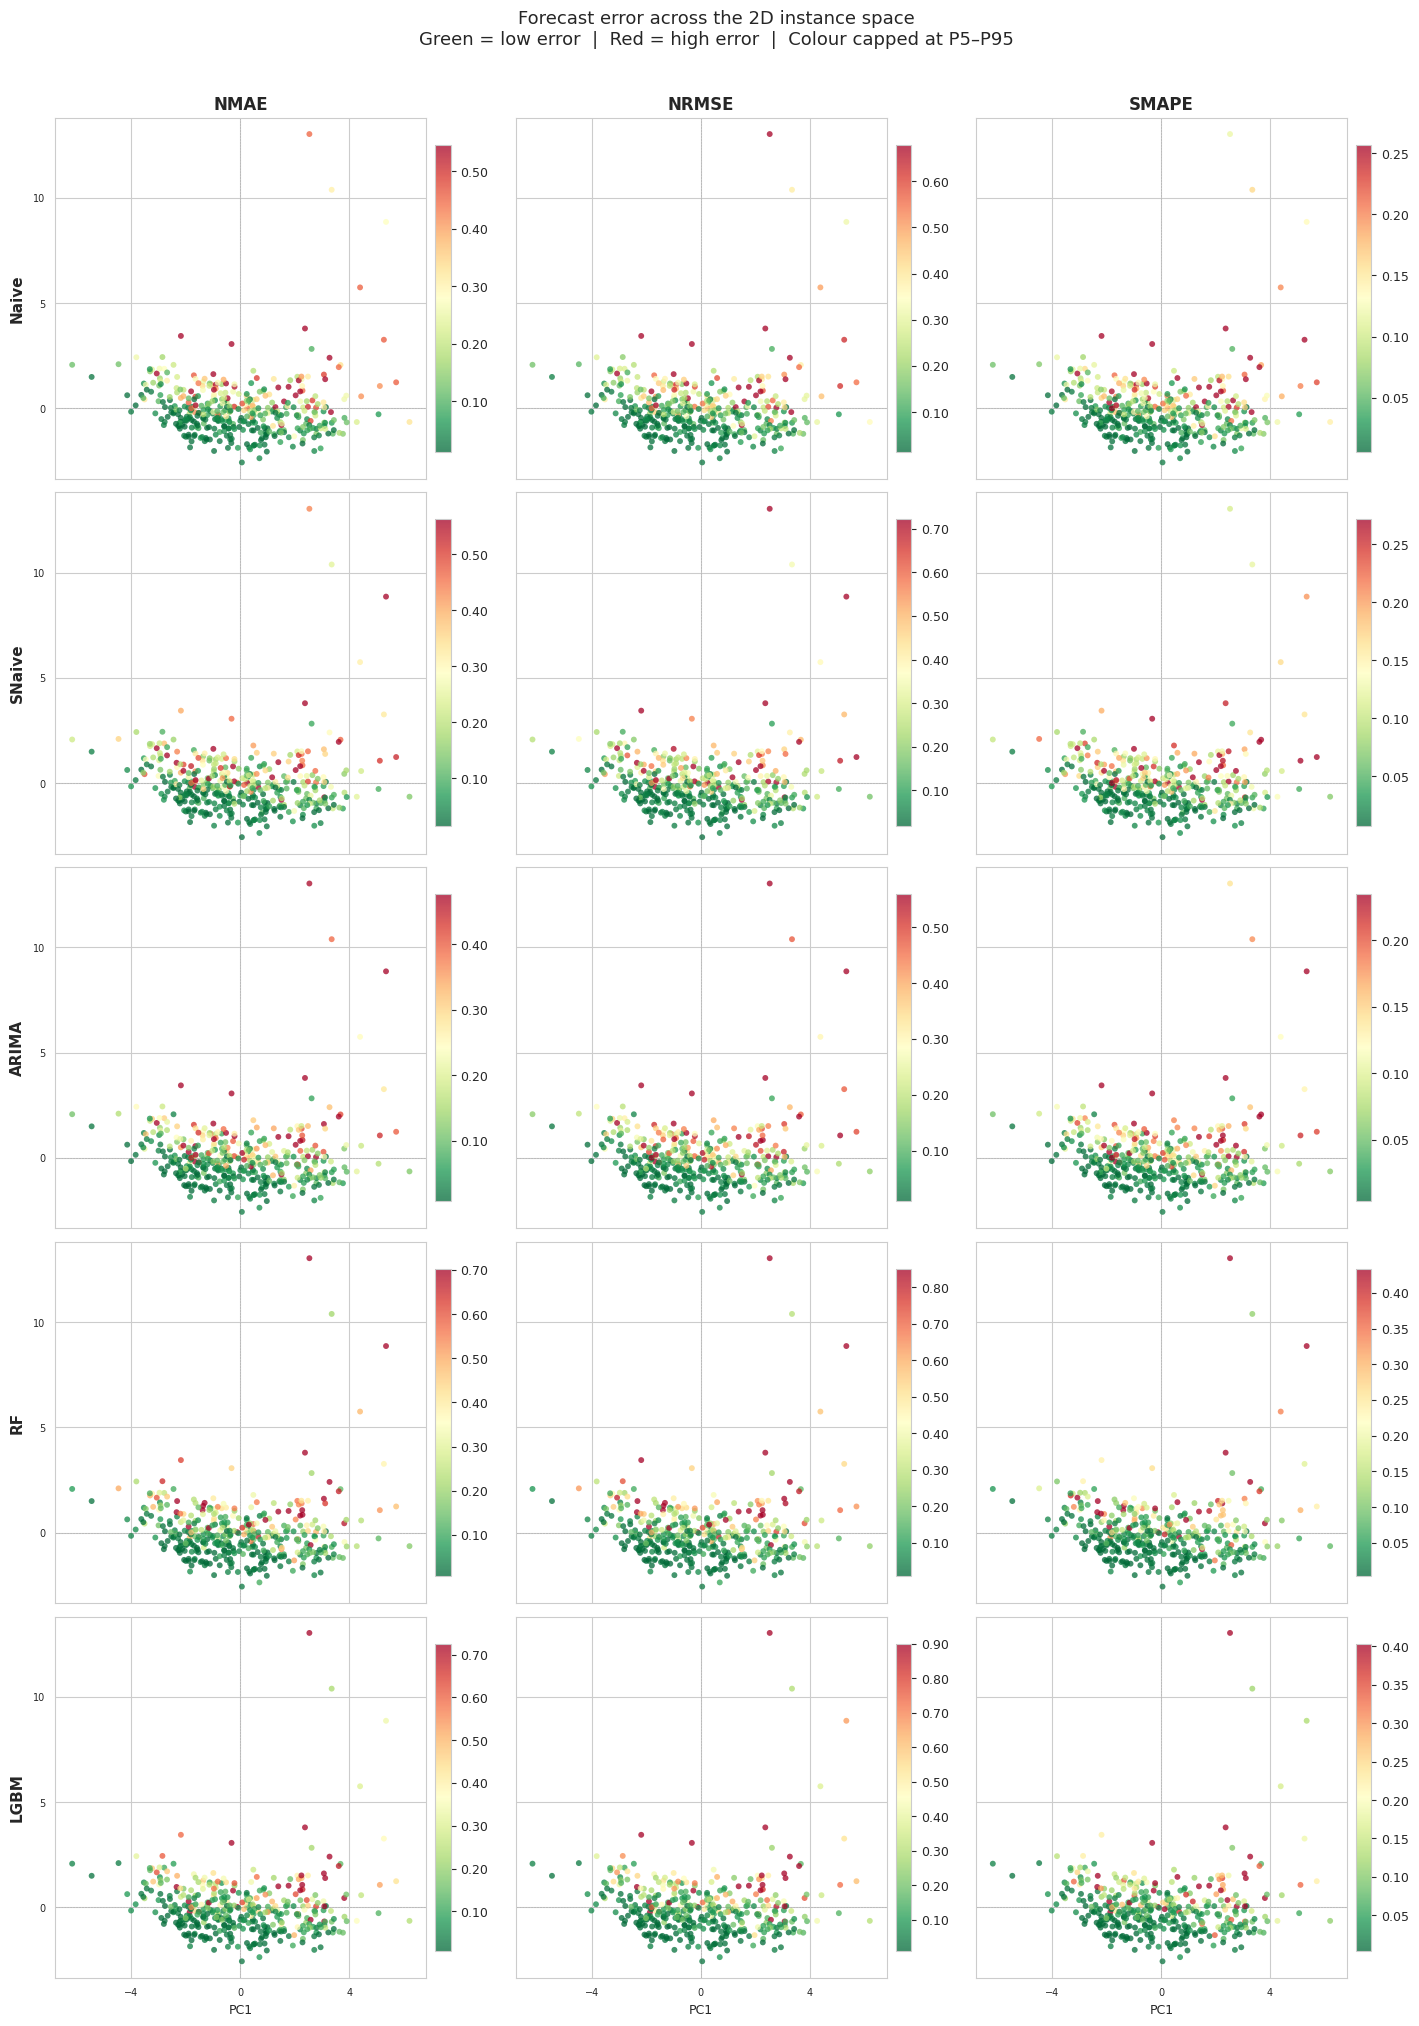

Saved: instance_space_model_performance.png

Median error by model and metric:
        nmae_median  nrmse_median  smape_median
Model                                          
Naive        0.0901        0.1131        0.0452
SNaive       0.1011        0.1191        0.0515
ARIMA        0.0726        0.0886        0.0363
RF           0.0929        0.1135        0.0481
LGBM         0.0888        0.1130        0.0451

Mean error by model and metric:
        nmae_mean  nrmse_mean  smape_mean
Model                                    
Naive      0.1721      0.2028      0.0815
SNaive     0.1805      0.2179      0.0849
ARIMA      0.1543      0.1846      0.0734
RF         0.2131      0.2533      0.1094
LGBM       0.2181      0.2573      0.1068


In [6]:
MODELS = {
    'Naive':  {'nmae': 'nmae_naive',         'nrmse': 'nrmse_naive',          'smape': 'smape_naive'},
    'SNaive': {'nmae': 'nmae_seasonal_naive', 'nrmse': 'nrmse_seasonal_naive', 'smape': 'smape_seasonal_naive'},
    'ARIMA':  {'nmae': 'nmae_AutoARIMA',      'nrmse': 'nrmse_AutoARIMA',      'smape': 'smape_AutoARIMA'},
    'RF':     {'nmae': 'nmae_RF',             'nrmse': 'nrmse_RF',             'smape': 'smape_RF'},
    'LGBM':   {'nmae': 'nmae_LGBM',           'nrmse': 'nrmse_LGBM',           'smape': 'smape_LGBM'},
}
METRICS      = ['nmae', 'nrmse', 'smape']
MODEL_NAMES  = list(MODELS.keys())
CAP_PCT      = 95

plot_df = final_df.dropna(subset=['PC1', 'PC2']).copy()
print(f"Series with valid PC1/PC2: {len(plot_df)}")

nrows = len(MODEL_NAMES)
ncols = len(METRICS)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4.8, nrows*4.0),
                         sharex=True, sharey=True)

for row_idx, model_name in enumerate(MODEL_NAMES):
    for col_idx, metric in enumerate(METRICS):
        ax  = axes[row_idx, col_idx]
        col = MODELS[model_name][metric]

        vals = plot_df[col].replace([np.inf, -np.inf], np.nan)
        mask = vals.notna()
        x, y, v = plot_df.loc[mask, 'PC1'].values, plot_df.loc[mask, 'PC2'].values, vals[mask].values

        vmin, vmax   = np.percentile(v, 100-CAP_PCT), np.percentile(v, CAP_PCT)
        v_clipped    = np.clip(v, vmin, vmax)

        sc = ax.scatter(x, y, c=v_clipped, cmap='RdYlGn_r',
                        vmin=vmin, vmax=vmax, s=18, alpha=0.75, edgecolors='none')
        plt.colorbar(sc, ax=ax, shrink=0.85, pad=0.02, format='%.2f')
        ax.axhline(0, color='gray', lw=0.4, ls='--', alpha=0.4)
        ax.axvline(0, color='gray', lw=0.4, ls='--', alpha=0.4)

        if row_idx == 0:
            ax.set_title(metric.upper(), fontsize=12, fontweight='bold', pad=6)
        if col_idx == 0:
            ax.set_ylabel(model_name, fontsize=11, fontweight='bold', labelpad=6)
        if row_idx == nrows-1:
            ax.set_xlabel('PC1', fontsize=9)

        ax.tick_params(labelsize=7)
        ax.xaxis.set_major_locator(MaxNLocator(4))
        ax.yaxis.set_major_locator(MaxNLocator(4))

fig.suptitle(
    'Forecast error across the 2D instance space\n'
    'Green = low error  |  Red = high error  |  Colour capped at P5–P95',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig('instance_space_model_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: instance_space_model_performance.png")

#Summary table
rows = []
for model_name in MODEL_NAMES:
    row = {'Model': model_name}
    for metric in METRICS:
        v = plot_df[MODELS[model_name][metric]].replace([np.inf, -np.inf], np.nan).dropna()
        row[f'{metric}_median'] = v.median()
        row[f'{metric}_mean']   = v.mean()
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index('Model')
print("\nMedian error by model and metric:")
print(summary_df[[c for c in summary_df.columns if 'median' in c]].round(4).to_string())
print("\nMean error by model and metric:")
print(summary_df[[c for c in summary_df.columns if 'mean' in c]].round(4).to_string())

## 7. Plot forecasting error with shared percentile-based colour limits

This version uses common 5th–95th percentile colour limits within each metric, making the plots easier to compare across models. The percentile cap prevents extreme errors from compressing the colour scale for the remaining series.

**Report references:** Section 4.2.2 (*Complexity Features and Forecasting Error*) and Figure 5.


Series with valid PC1/PC2: 400
NMAE scale: 0.0091 to 0.6142
NRMSE scale: 0.0111 to 0.7296
SMAPE scale: 0.0046 to 0.3129


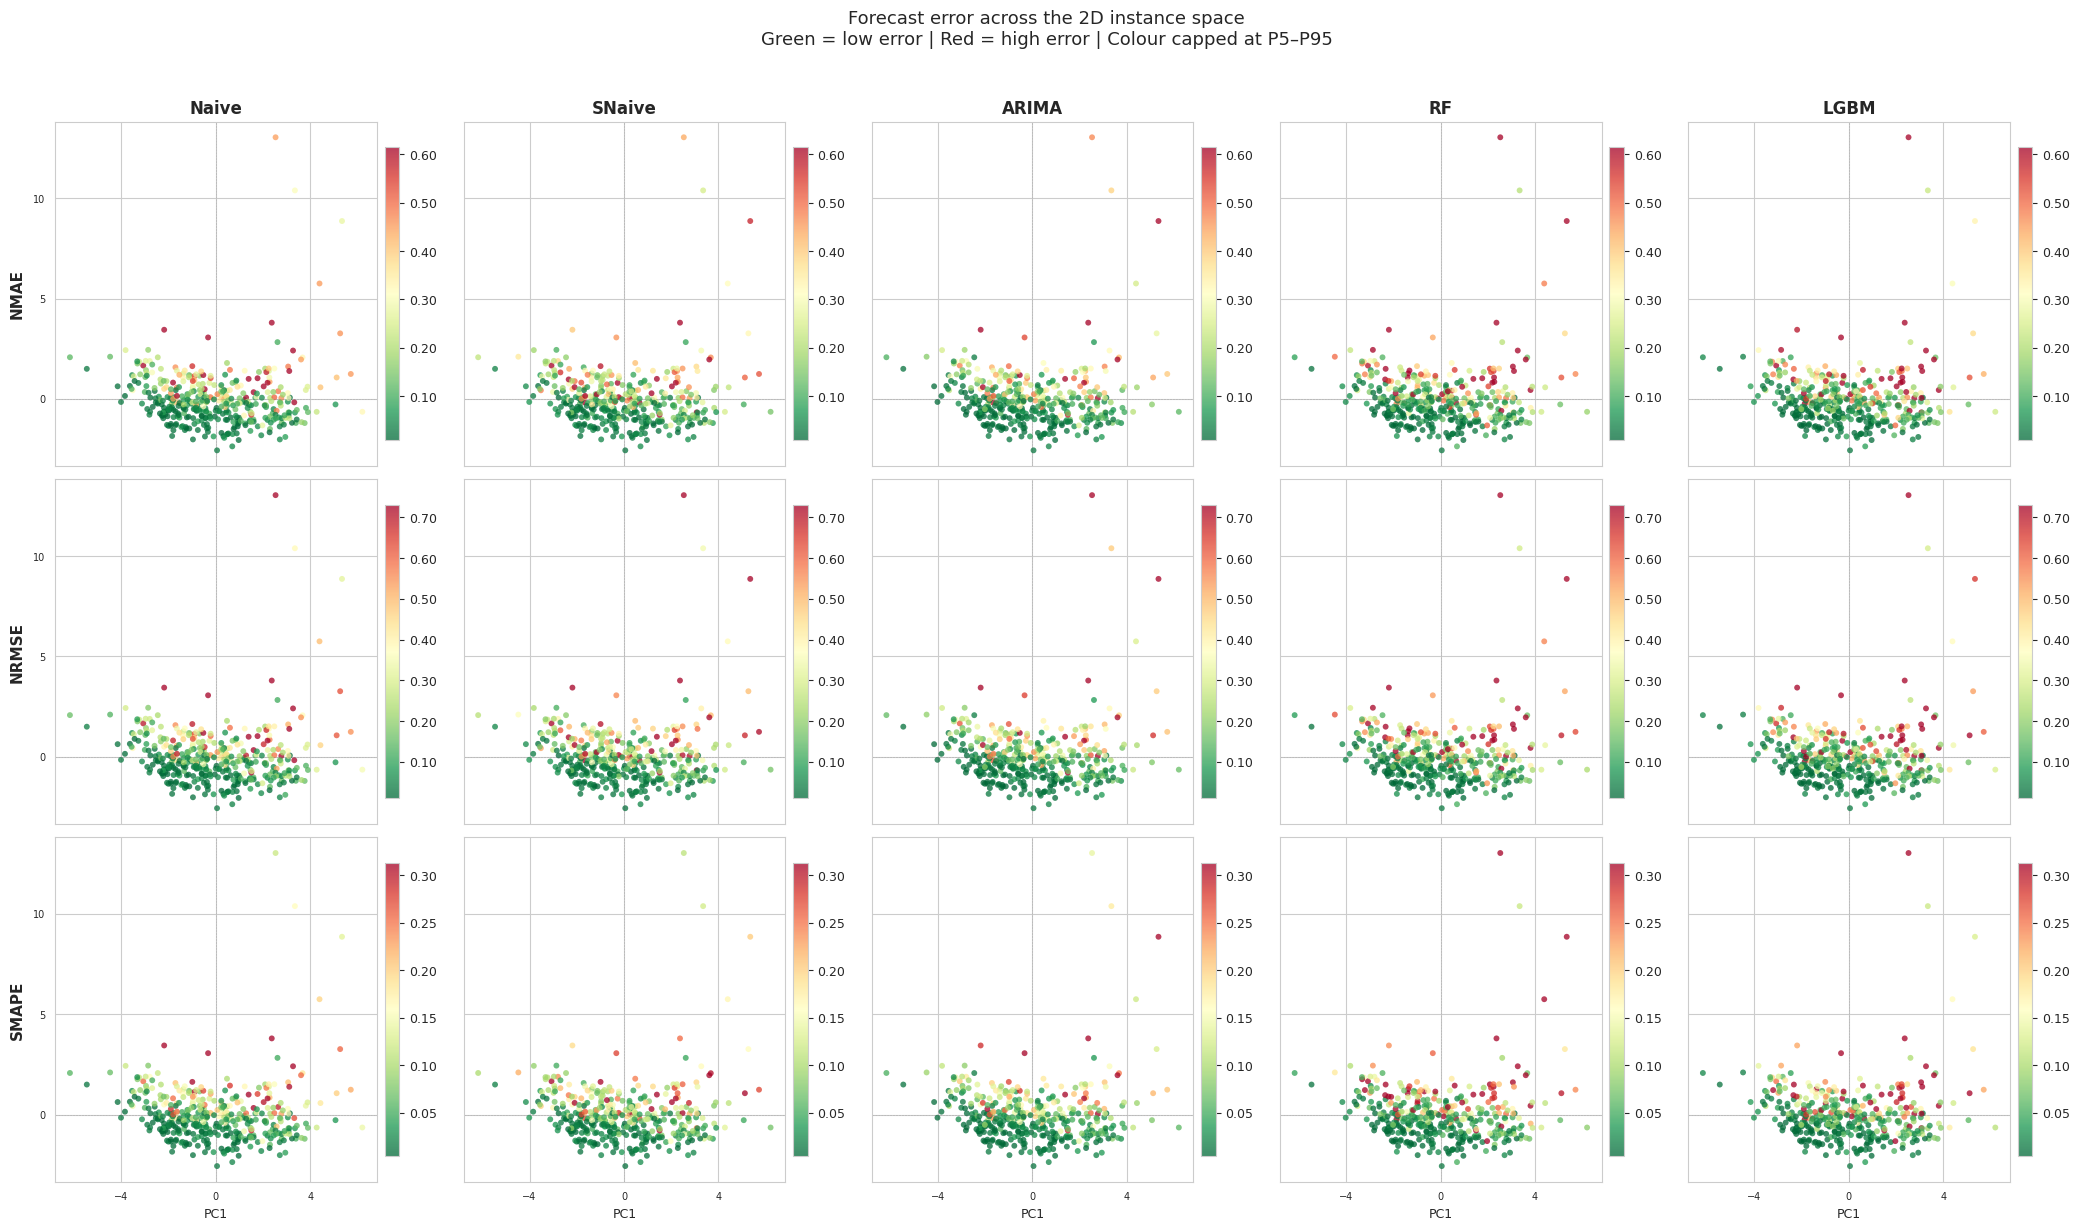

Saved: instance_space_model_performance_scaled.png
Saved: instance_space_model_performance_scaled.pdf

Median error by model and metric:
        nmae_median  nrmse_median  smape_median
Model                                          
Naive        0.0901        0.1131        0.0452
SNaive       0.1011        0.1191        0.0515
ARIMA        0.0726        0.0886        0.0363
RF           0.0929        0.1135        0.0481
LGBM         0.0888        0.1130        0.0451

Mean error by model and metric:
        nmae_mean  nrmse_mean  smape_mean
Model                                    
Naive      0.1721      0.2028      0.0815
SNaive     0.1805      0.2179      0.0849
ARIMA      0.1543      0.1846      0.0734
RF         0.2131      0.2533      0.1094
LGBM       0.2181      0.2573      0.1068


In [7]:
MODELS = {
    'Naive':  {'nmae': 'nmae_naive',           'nrmse': 'nrmse_naive',           'smape': 'smape_naive'},
    'SNaive': {'nmae': 'nmae_seasonal_naive', 'nrmse': 'nrmse_seasonal_naive', 'smape': 'smape_seasonal_naive'},
    'ARIMA':  {'nmae': 'nmae_AutoARIMA',      'nrmse': 'nrmse_AutoARIMA',      'smape': 'smape_AutoARIMA'},
    'RF':     {'nmae': 'nmae_RF',             'nrmse': 'nrmse_RF',             'smape': 'smape_RF'},
    'LGBM':   {'nmae': 'nmae_LGBM',           'nrmse': 'nrmse_LGBM',           'smape': 'smape_LGBM'},
}

METRICS = ['nmae', 'nrmse', 'smape']
MODEL_NAMES = list(MODELS.keys())
LOWER_PCT = 5
UPPER_PCT = 95

plot_df = final_df.dropna(subset=['PC1', 'PC2']).copy()

print(f"Series with valid PC1/PC2: {len(plot_df)}")

metric_limits = {}

for metric in METRICS:
    all_values = []

    for model_name in MODEL_NAMES:
        col = MODELS[model_name][metric]

        vals = (
            plot_df[col]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
            .values
        )

        all_values.extend(vals)

    all_values = np.array(all_values)

    metric_limits[metric] = (
        np.percentile(all_values, LOWER_PCT),
        np.percentile(all_values, UPPER_PCT)
    )

    print(
        f"{metric.upper()} scale: "
        f"{metric_limits[metric][0]:.4f} "
        f"to "
        f"{metric_limits[metric][1]:.4f}"
    )

nrows = len(METRICS)       # 3
ncols = len(MODEL_NAMES)   # 5

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(ncols * 4.2, nrows * 4.0),
    sharex=True,
    sharey=True
)

for row_idx, metric in enumerate(METRICS):

    for col_idx, model_name in enumerate(MODEL_NAMES):

        ax = axes[row_idx, col_idx]
        col = MODELS[model_name][metric]

        vals = plot_df[col].replace([np.inf, -np.inf], np.nan)
        mask = vals.notna()

        x = plot_df.loc[mask, 'PC1'].values
        y = plot_df.loc[mask, 'PC2'].values
        v = vals[mask].values

        vmin, vmax = metric_limits[metric]
        v_clipped = np.clip(v, vmin, vmax)

        sc = ax.scatter(
            x,
            y,
            c=v_clipped,
            cmap='RdYlGn_r',
            vmin=vmin,
            vmax=vmax,
            s=18,
            alpha=0.75,
            edgecolors='none'
        )

        plt.colorbar(
            sc,
            ax=ax,
            shrink=0.85,
            pad=0.02,
            format='%.2f'
        )

        ax.axhline(
            0,
            color='gray',
            lw=0.4,
            ls='--',
            alpha=0.4
        )

        ax.axvline(
            0,
            color='gray',
            lw=0.4,
            ls='--',
            alpha=0.4
        )

        # Column titles = models
        if row_idx == 0:
            ax.set_title(
                model_name,
                fontsize=12,
                fontweight='bold',
                pad=6
            )

        # Row labels = metrics
        if col_idx == 0:
            ax.set_ylabel(
                metric.upper(),
                fontsize=11,
                fontweight='bold',
                labelpad=6
            )

        # X label only on last row
        if row_idx == nrows - 1:
            ax.set_xlabel('PC1', fontsize=9)

        ax.tick_params(labelsize=7)
        ax.xaxis.set_major_locator(MaxNLocator(4))
        ax.yaxis.set_major_locator(MaxNLocator(4))

fig.suptitle(
    'Forecast error across the 2D instance space\n'
    'Green = low error | Red = high error | Colour capped at P5–P95',
    fontsize=13,
    y=1.02
)

plt.tight_layout()
plt.savefig(
    'instance_space_model_performance_scaled.png',
    dpi=300,
    bbox_inches='tight'
)

plt.savefig(
    'instance_space_model_performance_scaled.pdf',
    bbox_inches='tight'
)

plt.show()

print("Saved: instance_space_model_performance_scaled.png")
print("Saved: instance_space_model_performance_scaled.pdf")

rows = []

for model_name in MODEL_NAMES:

    row = {'Model': model_name}

    for metric in METRICS:

        v = (
            plot_df[MODELS[model_name][metric]]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        row[f'{metric}_median'] = v.median()
        row[f'{metric}_mean'] = v.mean()

    rows.append(row)

summary_df = pd.DataFrame(rows).set_index('Model')

print("\nMedian error by model and metric:")
print(
    summary_df[
        [c for c in summary_df.columns if 'median' in c]
    ].round(4).to_string()
)

print("\nMean error by model and metric:")
print(
    summary_df[
        [c for c in summary_df.columns if 'mean' in c]
    ].round(4).to_string()
)

## 8. Correlate complexity features with model-metric errors

This cell computes Spearman correlations between each complexity feature and each forecasting-error column. The goal is to identify which structural properties are most consistently associated with forecasting difficulty, complementing the earlier CE-only analysis.

**Report references:** Section 4.2.2 (*Complexity Features and Forecasting Error*) and Figure 4.

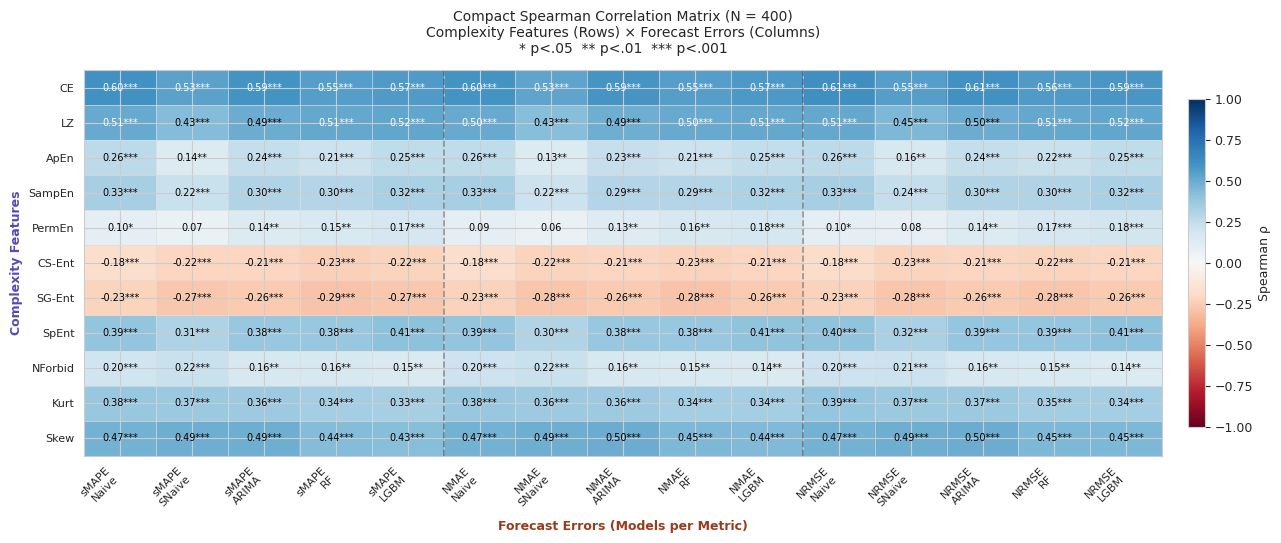

Saved: extended_correlation_matrix_horizontal.png
Saved: extended_correlation_matrix_horizontal.pdf

Correlation matrix (Spearman ρ):
         sMAPE\nNaive  sMAPE\nSNaive  sMAPE\nARIMA  sMAPE\nRF  sMAPE\nLGBM  NMAE\nNaive  NMAE\nSNaive  NMAE\nARIMA  NMAE\nRF  NMAE\nLGBM  NRMSE\nNaive  NRMSE\nSNaive  NRMSE\nARIMA  NRMSE\nRF  NRMSE\nLGBM
CE              0.603          0.535         0.594      0.549        0.568        0.600         0.529        0.592     0.553       0.571         0.613          0.553         0.606      0.565        0.586
LZ              0.505          0.432         0.493      0.509        0.516        0.503         0.426        0.486     0.505       0.511         0.510          0.449         0.496      0.510        0.519
ApEn            0.259          0.140         0.237      0.213        0.251        0.257         0.135        0.231     0.212       0.247         0.262          0.157         0.240      0.220        0.254
SampEn          0.330          0.222         0.300

In [8]:
def plot_extended_correlation_horizontal(final_df):
    COMPLEXITY_FEATURES = [
        'complexity_estimate', 'lempel_ziv', 'approximation_entropy', 'sample_entropy',
        'permutation_entropy', 'shannon_entropy_CS', 'shannon_entropy_SG',
        'spectral_entropy', 'nforbidden', 'kurtosis', 'skewness'
    ]

    METRIC_COLS = {
        'sMAPE\nNaive':  'smape_naive',
        'sMAPE\nSNaive': 'smape_seasonal_naive',
        'sMAPE\nARIMA':  'smape_AutoARIMA',
        'sMAPE\nRF':     'smape_RF',
        'sMAPE\nLGBM':   'smape_LGBM',

        'NMAE\nNaive':   'nmae_naive',
        'NMAE\nSNaive':  'nmae_seasonal_naive',
        'NMAE\nARIMA':   'nmae_AutoARIMA',
        'NMAE\nRF':      'nmae_RF',
        'NMAE\nLGBM':    'nmae_LGBM',

        'NRMSE\nNaive':  'nrmse_naive',
        'NRMSE\nSNaive': 'nrmse_seasonal_naive',
        'NRMSE\nARIMA':  'nrmse_AutoARIMA',
        'NRMSE\nRF':     'nrmse_RF',
        'NRMSE\nLGBM':   'nrmse_LGBM',
    }

    FEAT_LABELS = {
        'complexity_estimate': 'CE',
        'lempel_ziv': 'LZ',
        'approximation_entropy': 'ApEn',
        'sample_entropy': 'SampEn',
        'permutation_entropy': 'PermEn',
        'shannon_entropy_CS': 'CS-Ent',
        'shannon_entropy_SG': 'SG-Ent',
        'spectral_entropy': 'SpEnt',
        'nforbidden': 'NForbid',
        'kurtosis': 'Kurt',
        'skewness': 'Skew'
    }

    features_present = [f for f in COMPLEXITY_FEATURES if f in final_df.columns]
    feat_labels_present = [FEAT_LABELS.get(f, f) for f in features_present]

    metric_keys = list(METRIC_COLS.keys())
    metric_vals = list(METRIC_COLS.values())

    all_cols = features_present + metric_vals
    sub = final_df[all_cols].replace([np.inf, -np.inf], np.nan).dropna()
    n = len(sub)

    nf = len(features_present)
    nm = len(metric_vals)

    corr_mat = np.zeros((nf, nm))
    pval_mat = np.zeros((nf, nm))

    for i, feat in enumerate(features_present):
        for j, metr in enumerate(metric_vals):
            r, pv = spearmanr(sub[feat], sub[metr])
            corr_mat[i, j] = r
            pval_mat[i, j] = pv

    fig, ax = plt.subplots(figsize=(14, 5.5))

    im = ax.imshow(
        corr_mat,
        cmap='RdBu',
        vmin=-1,
        vmax=1,
        aspect='auto'
    )

    cbar = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
    cbar.set_label('Spearman ρ', fontsize=9)

    # Subtle grid
    ax.set_xticks(np.arange(nm) - 0.5, minor=True)
    ax.set_yticks(np.arange(nf) - 0.5, minor=True)
    ax.grid(which='minor', color='#DDDDDD', linestyle='-', linewidth=0.5)
    ax.tick_params(which='minor', bottom=False, left=False)

    # Vertical separators between metric blocks: sMAPE | NMAE | NRMSE
    for block_idx in range(5, nm, 5):
        ax.axvline(block_idx - 0.5, color='#444444', lw=1.2, ls='--', alpha=0.5)

    # Cell annotations
    for i in range(nf):
        for j in range(nm):
            v = corr_mat[i, j]
            pv = pval_mat[i, j]

            sig = (
                '***' if pv < 0.001 else
                '**' if pv < 0.01 else
                '*' if pv < 0.05 else
                ''
            )

            txt_color = 'white' if abs(v) > 0.50 else 'black'

            ax.text(
                j,
                i,
                f"{v:.2f}{sig}",
                ha='center',
                va='center',
                fontsize=7,
                color=txt_color
            )

    ax.set_xticks(range(nm))
    ax.set_yticks(range(nf))

    ax.set_xticklabels(metric_keys, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(feat_labels_present, fontsize=8)

    ax.set_xlabel(
        'Forecast Errors (Models per Metric)',
        fontsize=9,
        fontweight='bold',
        color='#993C1D',
        labelpad=8
    )

    ax.set_ylabel(
        'Complexity Features',
        fontsize=9,
        fontweight='bold',
        color='#534AB7'
    )

    ax.set_title(
        f'Compact Spearman Correlation Matrix (N = {n})\n'
        'Complexity Features (Rows) × Forecast Errors (Columns)\n'
        '* p<.05  ** p<.01  *** p<.001',
        fontsize=10,
        pad=12
    )

    plt.tight_layout()

    plt.savefig(
        'extended_correlation_matrix_horizontal.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.savefig(
        'extended_correlation_matrix_horizontal.pdf',
        bbox_inches='tight'
    )

    plt.show()

    print("Saved: extended_correlation_matrix_horizontal.png")
    print("Saved: extended_correlation_matrix_horizontal.pdf")

    cross = pd.DataFrame(
        corr_mat,
        index=feat_labels_present,
        columns=metric_keys
    )

    print("\nCorrelation matrix (Spearman ρ):")
    print(cross.round(3).to_string())

    return corr_mat, feat_labels_present, metric_keys

corr_mat, feat_labels, metric_labels = plot_extended_correlation_horizontal(final_df)

## 9. Assign the best model and estimate KDE confidence regions

For each series, the model with the lowest error is assigned as the best model for the selected metric. KDE contours are then estimated over the PCA coordinates of the series assigned to each model. This tests whether different models occupy clearly separated regions in the instance space.

**Report references:** Section 4.2.3 (*Best Model Assignment and Confidence Regions*) and Figure 6.



Best-model assignment (SMAPE):
  ARIMA   :  107 series  (26.8%)
  LGBM    :   77 series  (19.2%)
  Naive   :   76 series  (19.0%)
  RF      :   73 series  (18.2%)
  SNaive  :   67 series  (16.8%)


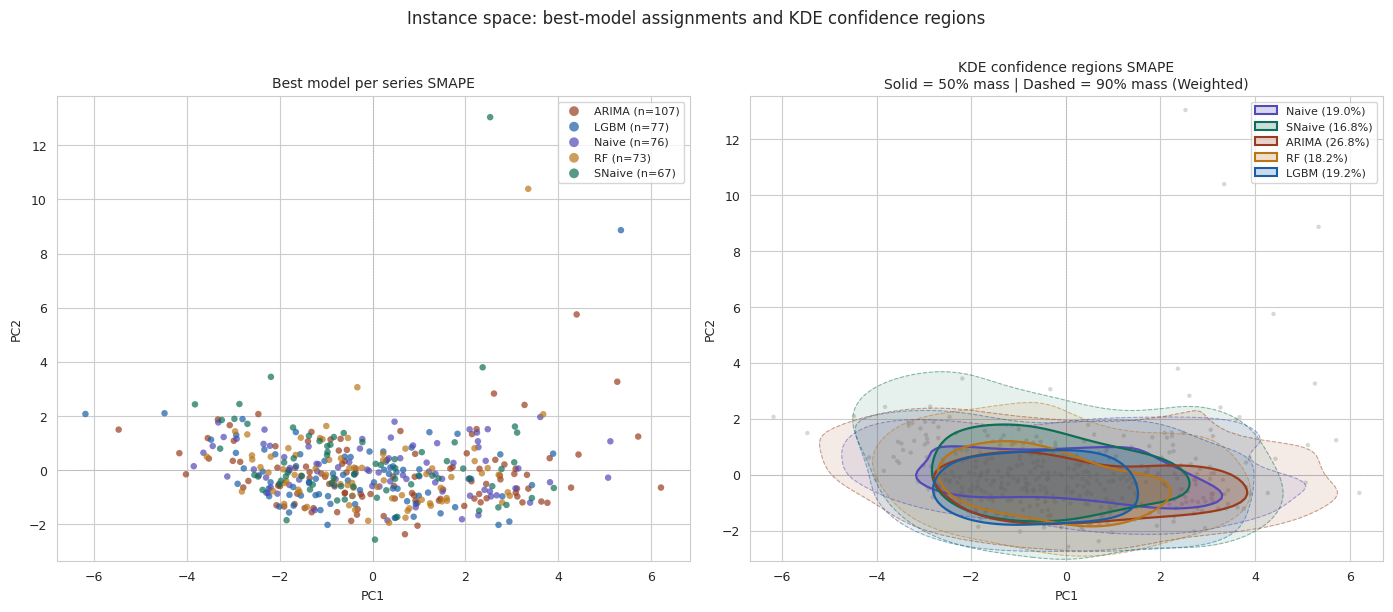

Saved: confidence_regions.png


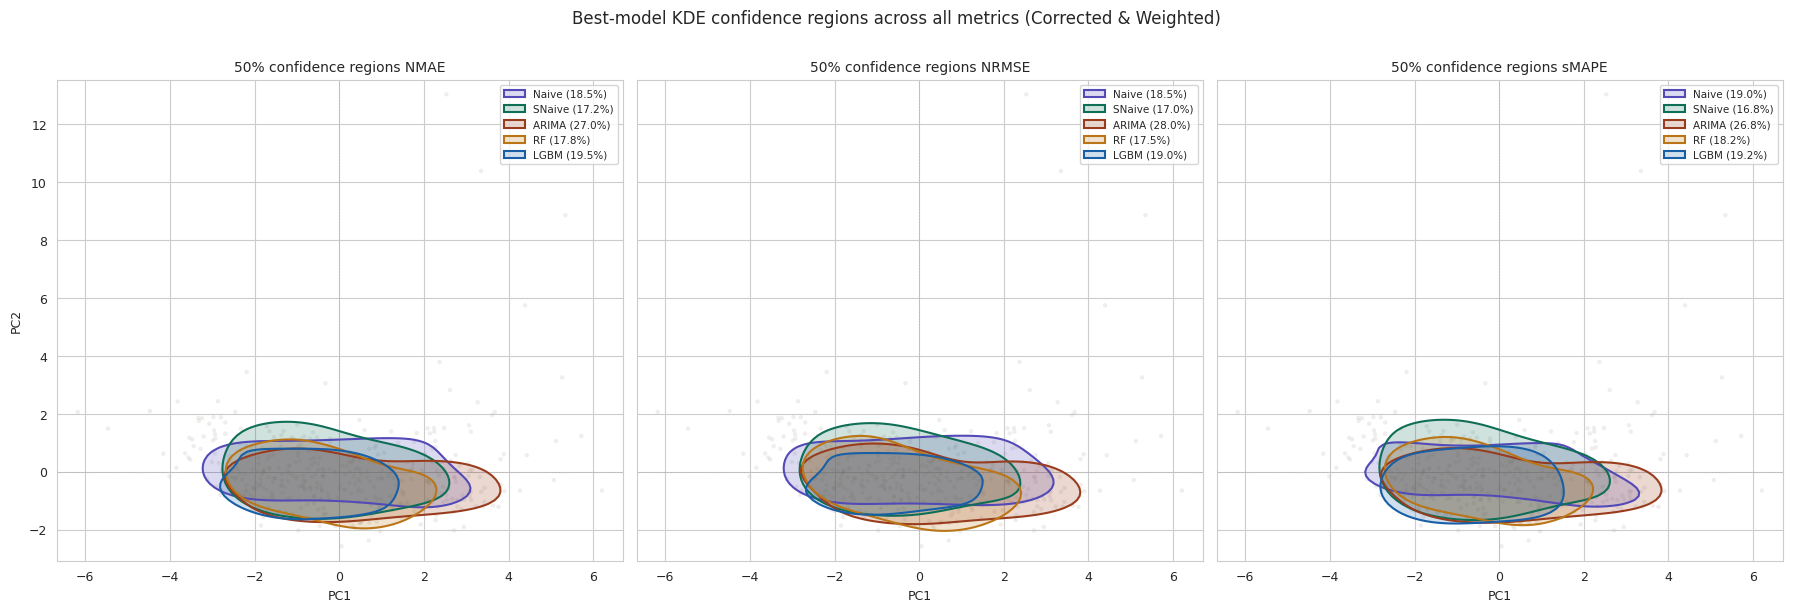

Saved: confidence_regions_all_metrics.png


In [9]:
def plot_confidence_regions(final_df, metric='smape', kde_bw='scott'): 
    MODELS = {
        'Naive':  f'{metric}_naive',
        'SNaive': f'{metric}_seasonal_naive',
        'ARIMA':  f'{metric}_AutoARIMA',
        'RF':     f'{metric}_RF',
        'LGBM':   f'{metric}_LGBM',
    }
 
    MODEL_COLORS = {
        'Naive':  '#534AB7',
        'SNaive': '#0F6E56',
        'ARIMA':  '#993C1D',
        'RF':     '#BA7517',
        'LGBM':   '#185FA5',
    }
 
    plot_df = final_df.dropna(subset=['PC1', 'PC2']).copy()
 
    #Best model assignment
    err_cols = {m: c for m, c in MODELS.items() if c in plot_df.columns}
    err_matrix = plot_df[[c for c in err_cols.values()]].replace([np.inf, -np.inf], np.nan)
    best_idx   = err_matrix.values.argmin(axis=1)
    model_list = list(err_cols.keys())
    plot_df['best_model'] = [model_list[i] for i in best_idx]
 
    counts = plot_df['best_model'].value_counts()
    print(f"\nBest-model assignment ({metric.upper()}):")
    for m, c in counts.items():
        print(f"  {m:8s}: {c:4d} series  ({100*c/len(plot_df):.1f}%)")
 
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
    ax = axes[0]
    for model_name, grp in plot_df.groupby('best_model'):
        c = MODEL_COLORS.get(model_name, 'gray')
        ax.scatter(grp['PC1'], grp['PC2'],
                   c=c, s=22, alpha=0.7, edgecolors='none',
                   label=f"{model_name} (n={len(grp)})")
    ax.axhline(0, color='gray', lw=0.4, ls='--', alpha=0.4)
    ax.axvline(0, color='gray', lw=0.4, ls='--', alpha=0.4)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'Best model per series {metric.upper()}', fontsize=10)
    ax.legend(fontsize=8, markerscale=1.5)
 
    #KDE
    ax2 = axes[1]
    ax2.scatter(plot_df['PC1'], plot_df['PC2'],
                c='#C0BDB4', s=10, alpha=0.6, edgecolors='none', zorder=1)
    ax2.axhline(0, color='gray', lw=0.4, ls='--', alpha=0.4)
    ax2.axvline(0, color='gray', lw=0.4, ls='--', alpha=0.4)
 
    pc1_range = np.linspace(plot_df['PC1'].min() - 0.5, plot_df['PC1'].max() + 0.5, 120)
    pc2_range = np.linspace(plot_df['PC2'].min() - 0.5, plot_df['PC2'].max() + 0.5, 120)
    XX, YY    = np.meshgrid(pc1_range, pc2_range)
    positions = np.vstack([XX.ravel(), YY.ravel()])
 
    dx = pc1_range[1] - pc1_range[0]
    dy = pc2_range[1] - pc2_range[0]
    area_elemento = dx * dy
 
    legend_handles = []
    for model_name in model_list:
        grp = plot_df[plot_df['best_model'] == model_name]
        if len(grp) < 10:
            continue
        pts = np.vstack([grp['PC1'].values, grp['PC2'].values])
        try:
            kernel = stats.gaussian_kde(pts, bw_method=kde_bw)
        except Exception:
            continue
 
        Z = kernel(positions).reshape(XX.shape)
        
        proporcao_modelo = len(grp) / len(plot_df)
        Z = Z * proporcao_modelo
        
        Zflat = Z.ravel()
        sorted_Z = np.sort(Zflat)[::-1]
        
        #Real Probability Mass
        massa_probabilidade = sorted_Z * area_elemento
        cumsum = np.cumsum(massa_probabilidade)
        
        if cumsum[-1] > 0:
            cumsum_normalizado = cumsum / cumsum[-1]
        else:
            cumsum_normalizado = cumsum
            
        t50 = sorted_Z[np.searchsorted(cumsum_normalizado, 0.50)]
        t90 = sorted_Z[np.searchsorted(cumsum_normalizado, 0.90)]
 
        col  = MODEL_COLORS.get(model_name, 'gray')
        rgb  = mcolors.to_rgb(col)
 
        #90%
        ax2.contourf(XX, YY, Z, levels=[t90, max(Z.max(), t90 + 1e-9)],
                     colors=[(*rgb, 0.10)], zorder=2)
        ax2.contour(XX, YY, Z, levels=[t90],
                    colors=[(*rgb, 0.45)], linewidths=0.8,
                    linestyles='dashed', zorder=3)
 
        #50%
        ax2.contourf(XX, YY, Z, levels=[t50, max(Z.max(), t50 + 1e-9)],
                     colors=[(*rgb, 0.22)], zorder=4)
        ax2.contour(XX, YY, Z, levels=[t50],
                    colors=[col], linewidths=1.6, zorder=5)
 
        patch = mpatches.Patch(facecolor=(*rgb, 0.22), edgecolor=col,
                               linewidth=1.5, label=f"{model_name} ({proporcao_modelo*100:.1f}%)")
        legend_handles.append(patch)
 
    ax2.set_xlabel('PC1')
    ax2.set_ylabel('PC2')
    ax2.set_title(
        f'KDE confidence regions {metric.upper()}\n'
        'Solid = 50% mass | Dashed = 90% mass (Weighted)', fontsize=10
    )
    ax2.legend(handles=legend_handles, fontsize=8)
 
    plt.suptitle(
        'Instance space: best-model assignments and KDE confidence regions',
        fontsize=12, y=1.01
    )
    plt.tight_layout()
    plt.savefig('confidence_regions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: confidence_regions.png")
 
    #Plot das 3 métricas
    metrics = ['nmae', 'nrmse', 'smape']
    metric_labels = {'nmae': 'NMAE', 'nrmse': 'NRMSE', 'smape': 'sMAPE'}
    MODELS_ALL = {
        m: {
            'nmae':  f'nmae_{suf}',
            'nrmse': f'nrmse_{suf}',
            'smape': f'smape_{suf}',
        }
        for m, suf in [('Naive','naive'),('SNaive','seasonal_naive'),
                       ('ARIMA','AutoARIMA'),('RF','RF'),('LGBM','LGBM')]
    }
 
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)
    for ax_m, met in zip(axes, metrics):
        err_sub = plot_df[[MODELS_ALL[m][met] for m in model_list if MODELS_ALL[m][met] in plot_df.columns]]
        err_sub.columns = [m for m in model_list if MODELS_ALL[m][met] in plot_df.columns]
        valid_models = err_sub.columns.tolist()
        best_idx_m   = err_sub.replace([np.inf,-np.inf], np.nan).values.argmin(axis=1)
        plot_df[f'best_{met}'] = [valid_models[i] for i in best_idx_m]
 
        ax_m.scatter(plot_df['PC1'], plot_df['PC2'],
                     c='#C0BDB4', s=10, alpha=0.25, edgecolors='none')
        ax_m.axhline(0, color='gray', lw=0.4, ls='--', alpha=0.4)
        ax_m.axvline(0, color='gray', lw=0.4, ls='--', alpha=0.4)
 
        handles = []
        for model_name in valid_models:
            grp = plot_df[plot_df[f'best_{met}'] == model_name]
            if len(grp) < 8:
                continue
            pts = np.vstack([grp['PC1'].values, grp['PC2'].values])
            try:
                kernel = stats.gaussian_kde(pts, bw_method='scott')
            except Exception:
                continue
                
            Z = kernel(positions).reshape(XX.shape)
            
            proporcao_modelo = len(grp) / len(plot_df)
            Z = Z * proporcao_modelo
            
            Zflat = Z.ravel()
            sorted_Z = np.sort(Zflat)[::-1]
            
            massa_probabilidade = sorted_Z * area_elemento
            cumsum = np.cumsum(massa_probabilidade)
            
            if cumsum[-1] > 0:
                cumsum_normalizado = cumsum / cumsum[-1]
            else:
                cumsum_normalizado = cumsum
                
            t50 = sorted_Z[np.searchsorted(cumsum_normalizado, 0.50)]
            col = MODEL_COLORS.get(model_name, 'gray')
            rgb = mcolors.to_rgb(col)
            
            ax_m.contourf(XX, YY, Z, levels=[t50, max(Z.max(), t50 + 1e-9)],
                          colors=[(*rgb, 0.20)], zorder=2)
            ax_m.contour(XX, YY, Z, levels=[t50],
                         colors=[col], linewidths=1.5, zorder=3)
            
            handles.append(mpatches.Patch(
                facecolor=(*rgb, 0.20), edgecolor=col,
                linewidth=1.5, label=f"{model_name} ({proporcao_modelo*100:.1f}%)"))
 
        ax_m.set_title(f'50% confidence regions {metric_labels[met]}', fontsize=10)
        ax_m.set_xlabel('PC1')
        if ax_m is axes[0]:
            ax_m.set_ylabel('PC2')
        ax_m.legend(handles=handles, fontsize=7.5)
 
    plt.suptitle('Best-model KDE confidence regions across all metrics (Corrected & Weighted)', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig('confidence_regions_all_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: confidence_regions_all_metrics.png")
 
    return plot_df

gg_df = plot_confidence_regions(final_df, metric='smape')